# **Sequence-to-Sequence (Seq2Seq) Modeling**
**What is Seq2Seq?**

A neural network architecture designed to map input sequences of variable length to output sequences of variable length.

Introduced by Sutskever et al. (2014) for neural machine translation (NMT).

Core idea:

Encoder compresses input sequence into a context vector.

Decoder generates output sequence step by step, conditioned on the context vector and previously generated outputs.

Seq2Seq Algorithm (High-Level Steps)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [7]:
# ===========================
# 1. Load & Clean Dataset
# ===========================
df = pd.read_csv("data.csv")

print("Original size:", df.shape)

Original size: (118964, 2)


In [8]:
# Har English sentence ka ek hi Spanish translation rakho
df = df.groupby("english").first().reset_index()

print("After cleaning:", df.shape)
print(df.head(10))

After cleaning: (102904, 2)
                                             english  \
0         "A Happy New Year!" "I wish you the same!"   
1    "A rolling stone gathers no moss" is a proverb.   
2                           "Ah" is an interjection.   
3  "Any good news in today's paper?" "No, nothing...   
4                 "Anything else?" "No, that's all."   
5          "Are the drinks free?" "Only for ladies."   
6            "Are these cars yours?" "Yes they are."   
7    "Are these your books?" "No, they're not mine."   
8  "Are these your books?" "No, they're not my bo...   
9         "Are those your books?" "No, they aren't."   

                                             spanish  
0                 "¡Feliz año nuevo!" "¡Igualmente!"  
1  "Una piedra rodante no junta musgo" es un refrán.  
2                          "Ah" es una interjección.  
3  "¿Alguna buena noticia en el diario de hoy?" "...  
4                    "¿Algo más?" "No, eso es todo."  
5  "¿Las bebidas son grat

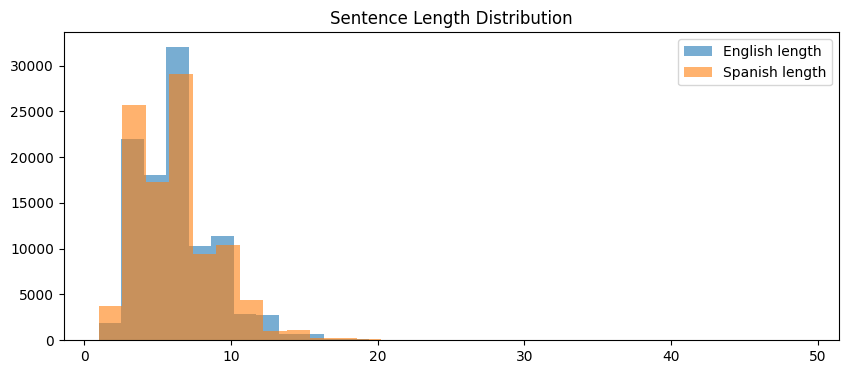

In [9]:
# 2. Data Visualization
# ===========================
df["eng_len"] = df["english"].apply(lambda x: len(x.split()))
df["spa_len"] = df["spanish"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,4))
plt.hist(df["eng_len"], bins=30, alpha=0.6, label="English length")
plt.hist(df["spa_len"], bins=30, alpha=0.6, label="Spanish length")
plt.legend()
plt.title("Sentence Length Distribution")
plt.show()

In [10]:
# 3. Tokenization
# ===========================
num_words = 10000  # limit vocab size for memory

src_tokenizer = Tokenizer(num_words=num_words, filters='')
src_tokenizer.fit_on_texts(df["english"])
tar_tokenizer = Tokenizer(num_words=num_words, filters='')
tar_tokenizer.fit_on_texts(df["spanish"])

# integer encode
encoder_input_sequences = src_tokenizer.texts_to_sequences(df["english"])
decoder_input_sequences = tar_tokenizer.texts_to_sequences(df["spanish"])

# add <eos> token by shifting sequences
tar_vocab_size = len(tar_tokenizer.word_index) + 1

max_encoder_len = max(len(seq) for seq in encoder_input_sequences)
max_decoder_len = max(len(seq) for seq in decoder_input_sequences)

encoder_input_data = pad_sequences(encoder_input_sequences, maxlen=max_encoder_len, padding="post")
decoder_input_data = pad_sequences(decoder_input_sequences, maxlen=max_decoder_len, padding="post")

# target shifted one step (for teacher forcing)
decoder_target_data = np.zeros_like(decoder_input_data)
decoder_target_data[:, :-1] = decoder_input_data[:, 1:]
decoder_target_data = np.expand_dims(decoder_target_data, -1)

In [11]:
# 4. Train-Test Split
# ===========================
enc_train, enc_val, dec_in_train, dec_in_val, dec_tgt_train, dec_tgt_val = train_test_split(
    encoder_input_data, decoder_input_data, decoder_target_data, test_size=0.1, random_state=42
)

In [12]:
# 5. Seq2Seq Model
# ===========================
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(len(src_tokenizer.word_index)+1, latent_dim)(encoder_inputs)
encoder_lstm = LSTM(latent_dim, return_state=True)
_, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(len(tar_tokenizer.word_index)+1, latent_dim)(decoder_inputs)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
decoder_dense = Dense(len(tar_tokenizer.word_index)+1, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

# Final Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, None, 128) │  3,052,672 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, None, 128) │  5,005,056 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ [(None, 128),     │    131,584 │ embedding_10[0][… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ [(None, None,     │    131,584 │ embedding_11[0][… │
│                     │ 128), (None,      │            │ lstm_10[0][1],    │
│                     │ 128), (None,      │            │ lstm_10[0][2]     │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, None,      │  5,044,158 │ lstm_11[0][0]     │
│                     │ 39102)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,365,054 (50.98 MB)

 Trainable params: 13,365,054 (50.98 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 6. Train Model
# ===========================
history = model.fit(
    [enc_train, dec_in_train], dec_tgt_train,
    batch_size=64,
    epochs=5,
    validation_data=([enc_val, dec_in_val], dec_tgt_val)
)

Epoch 1/5
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 295s 204ms/step - accuracy: 0.9034 - loss: 0.6679 - val_accuracy: 0.9019 - val_loss: 0.6731
Epoch 2/5
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 336s 214ms/step - accuracy: 0.9044 - loss: 0.6566 - val_accuracy: 0.9034 - val_loss: 0.6602
Epoch 3/5
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 310s 214ms/step - accuracy: 0.9048 - loss: 0.6498 - val_accuracy: 0.9048 - val_loss: 0.6516
Epoch 4/5
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 294s 203ms/step - accuracy: 0.9050 - loss: 0.6449 - val_accuracy: 0.9049 - val_loss: 0.6456
Epoch 5/5
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 309s 213ms/step - accuracy: 0.9056 - loss: 0.6384 - val_accuracy: 0.9050 - val_loss: 0.6415


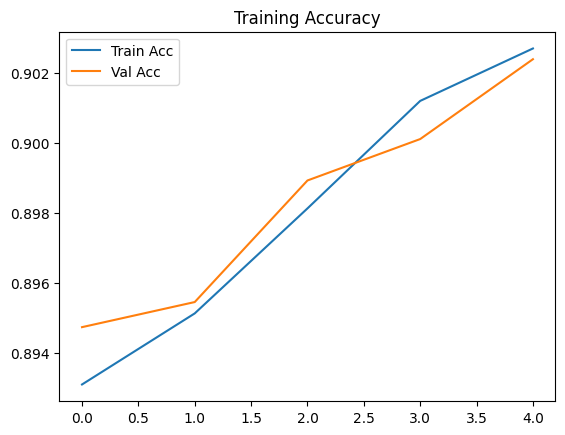

In [14]:
# 7. Plot Accuracy

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Training Accuracy")
plt.show()
